# Intro

The features that we have available to us
1. m/z
2. adducts
3. mqns (42): "c", "f", "cl", "br", "i", "s", "p", "an", "cn", "ao", "co",
    "hac", "hbam", "hba", "hbdm", "hbd", "neg", "pos", "asb", "adb",
    "atb", "csb", "cdb", "ctb", "rbc", "asv", "adv", "atv", "aqv",
    "cdv", "ctv", "cqv", "r3", "r4", "r5", "r6", "r7", "r8", "r9",
    "rg10", "afr", "bfr"
4. Fingerprints
5. Polarization


This notebook will focus on solving this problem through a Node-Level approach. Only one graph will exist and each node is a distinct molecule and each edge is a similarity embedding from one node to another.

Our goal is to predict CCS on the node level. By aggregating similar values seen through its nearest similar neighbours

# C3S Breakdown

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load Data
import sqlite3
import pandas as pd

conn = sqlite3.connect('/Users/reubensantoso/Xu_Lab_Files/c3s_neural_network/C3S.db')
cursor = conn.cursor()

master_df = pd.read_sql_query("SELECT * FROM master", conn)
mqn_df = pd.read_sql_query("SELECT * FROM mqns", conn)
fngr_df = pd.read_sql_query("SELECT * FROM fingerprints", conn)

c3s_df = pd.merge(master_df, fngr_df, on='g_id', how='left') #only added fingerprints. not mqn yet
c3s_df = c3s_df.dropna()
conn.close()

c3s_df.head()
print(c3s_df.shape)

(15187, 1036)


In [ ]:
pca_column = ["adv", "hac", "hbam", "c", "asb"]

final_mqn_col = mqn_df[pca_column]
print("Shape of set with chosen mqn: ", final_mqn_col.shape)

# Now perform the merge
c3s_df = c3s_df.join(final_mqn_col.set_index(c3s_df.index))

print("Current shape of dataset with master + finger + mqn: ", c3s_df.shape)
print(c3s_df.head())

Shape of set with chosen mqn:  (15187, 5)
Current shape of dataset with master + finger + mqn:  (15187, 1041)


## Adduct Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
adduct_groups = [
    "[M+H]+", "[M+Na]+", "[M-H]-", "[M+NH4]+", "[M+K]+",
    "[M+H-H2O]+", "[M+HCOO]-", "[M+CH3COO]-", "[M+Na-2H]-"
]

# Create OneHotEncoder
adduct_encoding = OneHotEncoder(
    sparse_output=False,
    categories='auto', #encodes every other adducts larger than 5
    handle_unknown="infrequent_if_exist",
    min_frequency=5 #needs to be above 5 data samples to be encoded. if below gets grouped to others
)

adduct_encoded = adduct_encoding.fit_transform(c3s_df[['adduct']])
adduct_encoded_df = pd.DataFrame(adduct_encoded)
print(adduct_encoded_df.shape)
print(adduct_encoded_df.head())

# Concatenate the original DataFrame with the one-hot encoded DataFrame
adduct_encoded_df.head()
c3s_df = c3s_df.join(adduct_encoded_df.set_index(c3s_df.index))
c3s_df.head()

(15187, 38)
    0    1    2    3    4    5    6    7    8    9   ...   28   29   30   31   
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  \
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

    32   33   34   35   36   37  
0  0.0  0.0  0.0  0.0  1.0  0.0  
1  0.0  0.0  0.0  0.0  1.0  0.0  
2  0.0  0.0  0.0  0.0  1.0  0.0  
3  0.0  0.0  0.0  0.0  1.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 38 columns]


,g_id,name,adduct,mass,z,mz,ccs,smi,chem_class_label,src_tag,...,28,29,30,31,32,33,34,35,36,37
0,CCSBASE_C4B6CF0FE6,1-Methylnicotinamide,[M]+,137.0715,1,137.0715,126.4,C[N+]1=CC=CC(=C1)C(=O)N,small molecule,zhou1016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,CCSBASE_D0DE2590C2,7-Methylguanosine,[M]+,298.1151,1,298.1151,166.5,CN1C=[N+](C2=C1C(=O)N=C(N2)N)[C@H]3[C@@H]([C@@...,small molecule,zhou1016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,CCSBASE_FC56BC6B13,Thiamine pyrophosphate,[M]+,425.0444,1,425.0444,182.0,CC1=C(SC=[N+]1CC2=CN=C(N=C2N)C)CCOP(=O)(O)OP(=...,small molecule,zhou1016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,CCSBASE_8A71E86DA2,beta-Nicotinamide D-ribonucleotide,[M]+,335.0639,1,335.0639,165.2,C1=CC(=C[N+](=C1)[C@H]2[C@@H]([C@@H]([C@H](O2)...,small molecule,zhou1016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,CCSBASE_D4448E3E51,Androsterone,[M+H-H2O]+,273.2218,1,273.2218,166.6,C[C@]12CC[C@H](C[C@@H]1CC[C@@H]3[C@@H]2CC[C@]4...,small molecule,zhou1016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Final Dataset

In [11]:
c3s_df_final = c3s_df.copy()
c3s_df_final = c3s_df_final.drop(columns=['g_id', 'adduct', 'name', 'mass', 'z', 'smi', 'chem_class_label', 'src_tag', 'ccs_type', 'ccs_method'], axis=1)

print(c3s_df_final.head())
print(c3s_df_final.columns)

         mz    ccs    0    1    2    3    4    5    6    7  ...   28   29   
0  137.0715  126.4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  \
1  298.1151  166.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2  425.0444  182.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
3  335.0639  165.2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
4  273.2218  166.6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  0.0  0.0   

    30   31   32   33   34   35   36   37  
0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 1069 columns]
Index([ 'mz', 'ccs',   '0',   '1',   '2',   '3',   '4',   '5',   '6',   '7',
       ...
          28,    29,    30,    31,    32,    33,    34,    35,    36,    37],
      dtype='object', length=1069)


# Building GNN - Train Set



In [12]:
print(c3s_df_final.shape)
print(c3s_df_final.columns)

(15187, 1069)
Index([ 'mz', 'ccs',   '0',   '1',   '2',   '3',   '4',   '5',   '6',   '7',
       ...
          28,    29,    30,    31,    32,    33,    34,    35,    36,    37],
      dtype='object', length=1069)


## Building Features

In [13]:
use_subset = False

if use_subset:
  c3s_df_final = c3s_df_final.sample(n=200, random_state=42)

print(c3s_df_final.shape)

(15187, 1069)


In [14]:
# features = ["mz", "adv", "hac", "hbam", "c", "asb", 'adduct_[M+H]+', 'adduct_[M+Na]+', 'adduct_[M-H]-', 'adduct_[M+NH4]+',
#        'adduct_[M+K]+', 'adduct_[M+H-H2O]+', 'adduct_[M+HCOO]-',
#        'adduct_[M+CH3COO]-', 'adduct_[M+Na-2H]-'] #15 features


c3s_target_df = c3s_df_final["ccs"]
c3s_featuers_df = c3s_df_final.drop("ccs", axis=1)


#c3s_df now has the full features we need for everything. Now train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    c3s_featuers_df, c3s_target_df, test_size=0.2, random_state=42
)

print("training and validation set")
print(X_train.shape)
print(y_train.shape)

print("test set")
print(X_test.shape)
print(y_test.shape)

training and validation set
(12149, 1068)
(12149,)
test set
(3038, 1068)
(3038,)


## Building Edges Knn

In [15]:
import torch
from torch_geometric.nn import GCNConv, global_mean_pool, SAGEConv
import torch.nn.functional as F
from torch.nn import Linear
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float)
y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float)

X_test_tensor = torch.tensor(X_test.values.astype(np.float32), dtype=torch.float)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float)

In [17]:
from sklearn.neighbors import NearestNeighbors

if "g_id" in fngr_df.columns:
    fngr_df = fngr_df.drop(columns=["g_id"])


#1. Building Graph for Train Set
knn = NearestNeighbors(n_neighbors=5, metric='jaccard') #use jaccard similarity to find 5 nearest neighbours
knn.fit(X_train[fngr_df.columns]) # Fit the nearest neighbors estimator from the training dataset based on fingerprints

# Compute the (weighted) graph of k-Neighbors for points in X. returns a list of edges
knn_graph_train = knn.kneighbors_graph(X_train[fngr_df.columns], mode='connectivity').tocoo()
edge_index_train = torch.tensor(np.array([knn_graph_train.row, knn_graph_train.col]), dtype=torch.long)


#2. Building graph for Test Set
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

knn = NearestNeighbors(n_neighbors=5, metric='jaccard')
knn.fit(X_test[fngr_df.columns])  # must match column structure

knn_graph_test = knn.kneighbors_graph(X_test[fngr_df.columns], mode='connectivity').tocoo()
edge_index_test = torch.tensor(np.array([knn_graph_test.row, knn_graph_test.col]), dtype=torch.long)

/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [18]:
print(edge_index_train.shape)
print("\n")
print(edge_index_test.shape)

torch.Size([2, 60745])


torch.Size([2, 15190])


## So right now we have the following variables for training:
1. Pandas Dataframes: X_train, X_test, y_train, y_test
2. Tensors: X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor
3. Edge List: edge_index_train, edge_index_test

In [19]:
def train(model, data, num_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    criterion = nn.MSELoss()

    train_history = []
    val_history = []

    for epoch in range(num_epochs):
        # --- Train phase ---
        model.train()
        optimizer.zero_grad()
        out = model(data) #the predicted data

        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()

        optimizer.step()
        train_loss = loss.item() # Returns Mean Squared Error (MSE) — not the sum of differences.
        train_history.append(train_loss)

        # --- Val phase ---
        model.eval()
        with torch.no_grad():
            val_out = model(data)
            val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])
            val_loss_item = val_loss.item()
            val_history.append(val_loss_item)

            # --- True MRE calculation --- (not MRE Loss)
            abs_y_error_train = torch.abs(out[data.train_mask] - data.y[data.train_mask])
            mre_train = torch.mean(100. * abs_y_error_train / data.y[data.train_mask])

            abs_y_error_val = torch.abs(val_out[data.val_mask] - data.y[data.val_mask])
            mre_val = torch.mean(100. * abs_y_error_val / data.y[data.val_mask])

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss_item:.4f}")
        print(f"True MRE Train: {mre_train:.4f}, True MRE Val: {mre_val:.4f}")

    return train_history, val_history, model


# Example plot function to visualize the loss histories
def plot_history(histories):
    for h in histories:
        epochs = range(1, len(h['train_loss']) + 1)
        plt.plot(epochs, h['train_loss'], label=f"{h['name']} Train Loss")
        plt.plot(epochs, h['val_loss'], label=f"{h['name']} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [20]:
class GNN_NodeLevel(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, hidden3):
        """
        GNN for node-level regression (CCS prediction per molecule node).
        """
        super(GNN_NodeLevel, self).__init__()
        torch.manual_seed(1234)

        # self.dropout_rates = [0.5, 0.3]

        self.conv1 = SAGEConv(input_dim, hidden1, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden1)

        self.conv2 = SAGEConv(hidden1, hidden2, aggr='mean')
        self.bn2 = nn.BatchNorm1d(hidden2)

        self.conv3 = SAGEConv(hidden2, hidden3, aggr='mean')
        self.bn3 = nn.BatchNorm1d(hidden3)

        self.output = Linear(hidden3, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.dropout_rates[0], training=self.training)

        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.dropout_rates[1], training=self.training)

        x = self.output(x)
        return x.squeeze()  # transforms the data into: [num_nodes, 1]

In [21]:
# Training Node Level Model
from sklearn.model_selection import KFold
from itertools import product
from torch_geometric.utils import subgraph
from torch_geometric.data import Data
import time

data_train_val = Data(
    x=X_train_tensor,
    y=y_train_tensor,
    edge_index=edge_index_train
).to(device)

data_test = Data(
    x=X_test_tensor,
    y=y_test_tensor,
    edge_index=edge_index_test
).to(device)


learning_rates = [0.001, 0.01, 0.1]
hidden_layer_configs = [
    (520, 260, 130),
    (128, 64, 32),
    (256, 128, 64),
]

grid = list(product(learning_rates, hidden_layer_configs))


=== Grid 1/9 | LR=0.001, Hidden=(520,260,130) ===
Fold 1/3
Epoch 1/120 | Train Loss: 49197.6719, Val Loss: 48401.3203
True MRE Train: 99.8502, True MRE Val: 98.7231
Epoch 2/120 | Train Loss: 49015.2695, Val Loss: 48141.0586
True MRE Train: 99.9771, True MRE Val: 98.5153
Epoch 3/120 | Train Loss: 48907.9688, Val Loss: 47950.1562
True MRE Train: 99.9782, True MRE Val: 98.3928
Epoch 4/120 | Train Loss: 48834.3242, Val Loss: 47807.7578
True MRE Train: 99.9653, True MRE Val: 98.3366
Epoch 5/120 | Train Loss: 48778.1133, Val Loss: 47720.1914
True MRE Train: 99.9412, True MRE Val: 98.3338
Epoch 6/120 | Train Loss: 48727.2578, Val Loss: 47665.4883
True MRE Train: 99.9095, True MRE Val: 98.3618
Epoch 7/120 | Train Loss: 48681.7852, Val Loss: 47657.7188
True MRE Train: 99.8692, True MRE Val: 98.4311
Epoch 8/120 | Train Loss: 48644.4805, Val Loss: 47681.5469
True MRE Train: 99.8317, True MRE Val: 98.5204
Epoch 9/120 | Train Loss: 48607.4609, Val Loss: 47731.7227
True MRE Train: 99.7912, True MRE

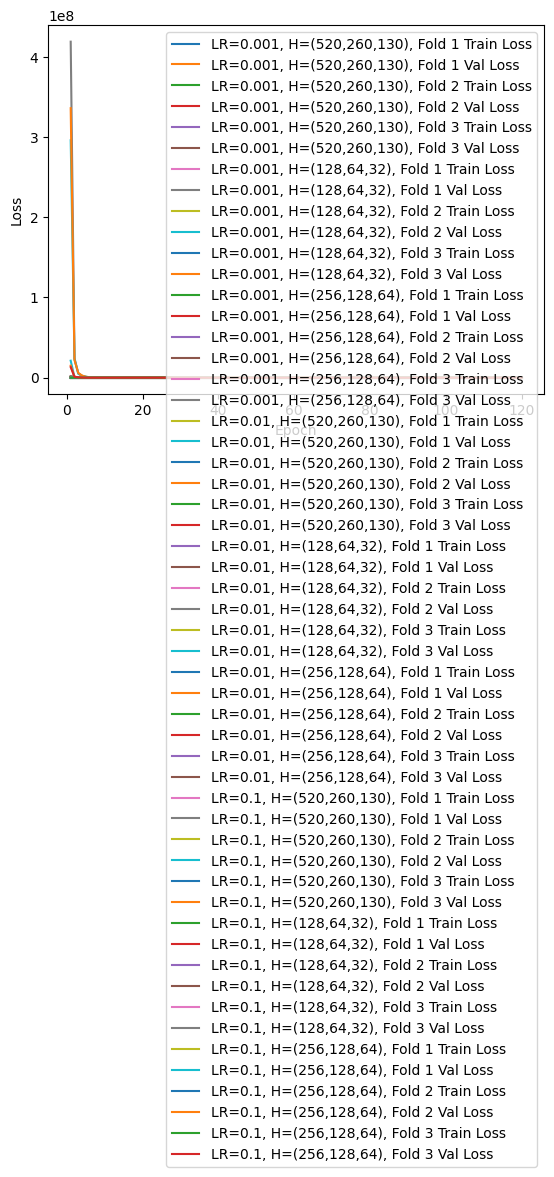

In [22]:
# Track best model
best_model = None
best_params = None

best_val_mre = float('inf')
best_train_mre = float('inf')

# Store all histories
all_histories = []

# Loop over grid of hyperparameters
for i, (lr, (h1, h2, h3)) in enumerate(grid):
    print(f"\n=== Grid {i+1}/{len(grid)} | LR={lr}, Hidden=({h1},{h2},{h3}) ===")

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_train_mres = []
    fold_val_mres = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_train_val.x)):
        print(f"Fold {fold+1}/{kf.get_n_splits()}")

        # Combine all indices and build subgraph
        all_idx = torch.tensor(train_idx.tolist() + val_idx.tolist(), dtype=torch.long)
        edge_index_sub, _ = subgraph(subset=all_idx, edge_index=data_train_val.edge_index, relabel_nodes=True)

        x_sub = data_train_val.x[all_idx] #grabs features from masked index
        y_sub = data_train_val.y[all_idx] #grabs target from masked target

        train_idx_new = torch.arange(len(train_idx))
        val_idx_new = torch.arange(len(train_idx), len(all_idx))

        data_fold = Data(x=x_sub, y=y_sub, edge_index=edge_index_sub) #creates a new data fold with the index masking
        mask = torch.zeros(len(all_idx), dtype=torch.bool)

        data_fold.train_mask = mask.clone()
        data_fold.train_mask[train_idx_new] = True #activate the index for train feeding
        data_fold.val_mask = mask.clone()
        data_fold.val_mask[val_idx_new] = True

        # Train the model
        model = GNN_NodeLevel(input_dim=data_fold.num_features, hidden1=h1, hidden2=h2, hidden3=h3).to(device)
        data_fold = data_fold.to(device)
        train_hist, val_hist, trained_model = train(model, data_fold, num_epochs=120, learning_rate=lr)

        # Inference for final fold MREs
        model.eval()
        with torch.no_grad():
            preds = model(data_fold)
            y_true = data_fold.y

            abs_y_error_train = torch.abs(preds[data_fold.train_mask] - data_fold.y[data_fold.train_mask])
            train_mre = torch.mean(100. * abs_y_error_train / data_fold.y[data_fold.train_mask])

            abs_y_error_val = torch.abs(preds[data_fold.val_mask] - data_fold.y[data_fold.val_mask])
            val_mre = torch.mean(100. * abs_y_error_val / data_fold.y[data_fold.val_mask])

        fold_train_mres.append(train_mre)
        fold_val_mres.append(val_mre)

        # Save history for plotting
        all_histories.append({
            'name': f'LR={lr}, H=({h1},{h2},{h3}), Fold {fold+1}',
            'train_loss': train_hist,
            'val_loss': val_hist
        })

    # Average MREs across folds of this setting
    avg_train_mre = sum(fold_train_mres) / len(fold_train_mres)
    avg_val_mre = sum(fold_val_mres) / len(fold_val_mres)
    print(f"Avg Train MRE: {avg_train_mre:.4f}, Avg Val MRE: {avg_val_mre:.4f}")

    if avg_val_mre < best_val_mre:
        best_val_mre = avg_val_mre
        best_train_mre = avg_train_mre
        best_model = trained_model
        best_params = {'lr': lr, 'hidden': (h1, h2, h3)}


# Final best config
print(f"\n✅ Best Config: LR={best_params['lr']}, Hidden={best_params['hidden']}")
print(f"📉 Best Train MRE%: {best_train_mre:.4f}, Best Val MRE: {best_val_mre:.4f}")

# Plot all histories
plot_history(all_histories)

# Retrain on Full Train Set

In [23]:
print(best_params)
print(best_model)

{'lr': 0.1, 'hidden': (128, 64, 32)}
GNN_NodeLevel(
  (conv1): SAGEConv(1068, 128, aggr=mean)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(128, 64, aggr=mean)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): SAGEConv(64, 32, aggr=mean)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [24]:
# Create full train mask (all nodes included)
data_train_val.train_mask = torch.ones(data_train_val.num_nodes, dtype=torch.bool)
data_train_val.val_mask = torch.zeros(data_train_val.num_nodes, dtype=torch.bool)  # no val phase now

# Build model with best hyperparameters
best_gnn_model = GNN_NodeLevel(
    input_dim=data_train_val.num_features,
    hidden1=best_params['hidden'][0],
    hidden2=best_params['hidden'][1],
    hidden3=best_params['hidden'][2]
).to(device)

# Retrain model on all training data
train_hist, _, best_gnn_model = train(
    best_gnn_model,
    data_train_val,
    num_epochs=350,
    learning_rate=best_params['lr']
)

Epoch 1/350 | Train Loss: 49271.5938, Val Loss: nan
True MRE Train: 99.8810, True MRE Val: nan
Epoch 2/350 | Train Loss: 48609.0469, Val Loss: nan
True MRE Train: 99.3007, True MRE Val: nan
Epoch 3/350 | Train Loss: 47588.7188, Val Loss: nan
True MRE Train: 98.4598, True MRE Val: nan
Epoch 4/350 | Train Loss: 46359.2773, Val Loss: nan
True MRE Train: 97.5308, True MRE Val: nan
Epoch 5/350 | Train Loss: 44974.8359, Val Loss: nan
True MRE Train: 96.2892, True MRE Val: nan
Epoch 6/350 | Train Loss: 43343.3789, Val Loss: nan
True MRE Train: 94.8926, True MRE Val: nan
Epoch 7/350 | Train Loss: 41498.7812, Val Loss: nan
True MRE Train: 93.1638, True MRE Val: nan
Epoch 8/350 | Train Loss: 39415.0742, Val Loss: nan
True MRE Train: 90.9995, True MRE Val: nan
Epoch 9/350 | Train Loss: 37111.4258, Val Loss: nan
True MRE Train: 88.5640, True MRE Val: nan
Epoch 10/350 | Train Loss: 34602.2461, Val Loss: nan
True MRE Train: 85.8185, True MRE Val: nan
Epoch 11/350 | Train Loss: 31893.1582, Val Loss: 

In [25]:
best_gnn_model.eval()
with torch.no_grad(): # disables gradient calculation -> no intermediate tensors will be saved for backpropagation
    test_preds = best_gnn_model(data_test)
    test_mre = (100 * torch.abs(test_preds - data_test.y) / (data_test.y)).mean()

print(f"\n🏁 Final Test MRE using Best Config: {test_mre:.4f}")


🏁 Final Test MRE using Best Config: 3.2985


In [26]:
with torch.no_grad():
    y_pred_train = best_gnn_model(data_train_val) #predicted values from train
    y_pred_test = best_gnn_model(data_test) #predicted values from test

#convert to numpy
y_train_np = data_train_val.y.detach().cpu().numpy()
y_test_np = data_test.y.detach().cpu().numpy()
y_pred_train_np = y_pred_train.detach().cpu().numpy()
y_pred_test_np = y_pred_test.detach().cpu().numpy()

In [27]:
from typing import Dict, List
from matplotlib.gridspec import GridSpec
from numpy import typing as npt
from sklearn.metrics import r2_score, mean_squared_error

def compute_metrics(y: npt.NDArray[np.float64],
                    y_pred: npt.NDArray[np.float64]
                    ) -> Dict[str, float | List[float]] :
    """
    compute a standard array of metrics between a set of predicted and reference values

    - R-squared (R2)
    - root mean squared error (RMSE)
    - mean absolute error (MAE)
    - median absolute erre (MDAE)
    - mean relative error % (MRE)
    - median relative error % (MDRE)
    - cumulative error distribution at the <1, <3, <5, and <10% levels (CE135A)

    Parameters
    ----------
    y : ``numpy.ndarray(float)``
    y_pred : ``numpy.ndarray(float)``
        arrays of reference and predicted values

    Returns
    -------
    summary : ``dict(...)``
        dict with set of metrics
    """
    abs_y_err = np.abs(y_pred - y)
    r2 = r2_score(y, y_pred)
    mae = np.mean(abs_y_err)
    mdae = np.median(abs_y_err)
    mre = np.mean(100. * abs_y_err / y)
    mdre = np.median(100. * abs_y_err / y)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    y_err_percent = 100. * abs_y_err / y
    cum_err = np.cumsum(np.histogram(y_err_percent, [_ for _ in range(101)])[0])
    cum_err = 100. * cum_err / np.sum(cum_err)
    ce1, ce3, ce5, ceA = cum_err[0], cum_err[2], cum_err[4], cum_err[9]
    return {
        'R2': r2, 'MAE': mae, 'MDAE': mdae, 'MRE': mre, 'MDRE': mdre,
        'RMSE': rmse, 'CE135A': [ce1, ce3, ce5, ceA]
    }


def compute_metrics_train_test(y_train: npt.NDArray[np.float64],
                               y_test: npt.NDArray[np.float64],
                               y_pred_train: npt.NDArray[np.float64],
                               y_pred_test: npt.NDArray[np.float64]
                               ) -> Dict[str, Dict[str, float | List[float]]] :
    """
    computes a standard set of performance metrics from separate predictions
    for a training and test dataset
    - training and test set R-squared (R2)
    - training and test set root mean squared error (RMSE)
    - training and test set mean absolute error (MAE)
    - training and test set median absolute error (MDAE)
    - training and test set mean relative error (MRE)
    - training and test set median relative error (MDRE)
    - cumulative error distribution at the <1, <3, <5, and <10% levels
        for training and test set (CE135A)

    Parameters
    ----------
    y_train : ``numpy.ndarray(float)``
    y_test : ``numpy.ndarray(float)``
    y_pred_train : ``numpy.ndarray(float)``
    y_pred_test : ``numpy.ndarray(float)``
        arrays of reference and predicted values for training and test datasets

    Returns
    -------
    summary : ``dict(...)``
        dict with set of metrics for training and test datasets
    """
    summary = {}
    for y, y_pred, lbl in [(y_train, y_pred_train, "train"), (y_test, y_pred_test, "test")]:
        # compute metrics
        summary[lbl] = compute_metrics(y, y_pred)
    return summary

def train_test_summary_figure(summary: Dict[str, Dict[str, float | List[float]]],
                              fig_name: str,
                              r2_range=[0.95, 1.]):
    """
    produces a summary figure displaying the results from `compute_metrics_train_test`

    Parameters
    ----------
    summary : ``dict(...)``
        summary dict returned from `compute_metrics_train_test`
    fig_name : ``str``
        file name to save the generated plot under
    r2_range : ``list(float))``, default=[0.95, 1.]]
        lower and upper bounds of R-squared y axis
    """
    fig = plt.figure(figsize=(5, 3))
    gs = GridSpec(1, 4, figure=fig, width_ratios=[1.2, 3, 2, 5])

    # R-squared
    ax1 = fig.add_subplot(gs[0])
    rsq_trn = summary['train']['R2']
    rsq_tst = summary['test']['R2']
    w1 = 0.15
    ax1.bar([1 - w1 / 2, 1 + w1 / 2], [rsq_trn, rsq_tst], color=['b', 'r'], width=w1)
    for d in ['top', 'right']:
        ax1.spines[d].set_visible(False)
    ax1.set_xticks([])
    ax1.set_ylabel(r'R$^2$')
    ax1.set_ylim(r2_range)
    ax1.set_xlim([0.75, 1.25])

    # MAE, MDAE and RMSE
    ax2 = fig.add_subplot(gs[1])
    mae_trn = summary['train']['MAE']
    mae_tst = summary['test']['MAE']
    mdae_trn = summary['train']['MDAE']
    mdae_tst = summary['test']['MDAE']
    mse_trn = summary['train']['RMSE']
    mse_tst = summary['test']['RMSE']
    ax2.bar([0.875, 1.125], [mae_trn, mae_tst], color=['b', 'r'], width=0.25)
    ax2.bar([1.875, 2.125], [mdae_trn, mdae_tst], color=['b', 'r'], width=0.25)
    ax2.bar([2.875, 3.125], [mse_trn, mse_tst], color=['b', 'r'], width=0.25)
    for d in ['top', 'right']:
        ax2.spines[d].set_visible(False)
    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(['MAE', 'MDAE', 'RMSE'], rotation='vertical')
    ax2.set_ylabel(r'CCS (Å$^2$)')

    # CE135A
    ax3 = fig.add_subplot(gs[3])
    x1 = [_ - 0.125 for _ in range(1, 5)]
    y1 = [100. * summary['train']['CE135A'][i] for i in range(4)]
    x2 = [_ + 0.125 for _ in range(1, 5)]
    y2 = [100. * summary['test']['CE135A'][i] for i in range(4)]
    ax3.bar(x1, y1, color='b', width=0.25)
    ax3.bar(x2, y2, color='r', width=0.25)
    for d in ['top', 'right']:
        ax3.spines[d].set_visible(False)
    ax3.set_xlabel('pred. error (%)')
    ax3.set_xticks([1, 2, 3, 4])
    ax3.set_xticklabels(['<1', '<3', '<5', '<10'])
    ax3.set_ylabel('proportion (%)')
    # between axes 2 and 3

    # MRE, MDRE
    ax23 = fig.add_subplot(gs[2])
    mre_trn = summary['train']['MRE']
    mre_tst = summary['test']['MRE']
    mdre_trn = summary['train']['MDRE']
    mdre_tst = summary['test']['MDRE']
    w23 = 0.25
    ax23.bar([1 - w23 / 2, 1 + w23 / 2], [mre_trn, mre_tst], color=['b', 'r'], width=w23)
    ax23.bar([2 - w23 / 2, 2 + w23 / 2], [mdre_trn, mdre_tst], color=['b', 'r'], width=w23)
    for d in ['top', 'right']:
        ax23.spines[d].set_visible(False)
    ax23.set_xticks([1, 2])
    ax23.set_xticklabels(['MRE', 'MDRE'], rotation='vertical')
    ax23.set_ylabel('%')
    plt.tight_layout()
    plt.savefig(fig_name, dpi=400, bbox_inches='tight')

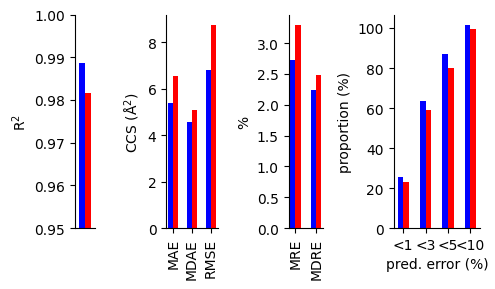

In [28]:
summary_new = compute_metrics_train_test(y_train_np, y_test_np, y_pred_train_np, y_pred_test_np)
train_test_summary_figure(summary_new, "metrics_gnn.png")

In [29]:
for key, metrics_dict in summary_new.items():
    print(key)  # This prints "train" or "test"
    for metric_name, value in metrics_dict.items():
        print(f"{metric_name}: {value}\n")

train
R2: 0.9886104446962953

MAE: 5.382761478424072

MDAE: 4.5773773193359375

MRE: 2.7257239818573

MDRE: 2.23220157623291

RMSE: 6.80478572845459

CE135A: [0.2541212608052057, 0.6358083632671001, 0.8676161270168454, 1.0165692450965038]

test
R2: 0.9816351028596763

MAE: 6.559675216674805

MDAE: 5.061546325683594

MRE: 3.2984776496887207

MDRE: 2.475770950317383

RMSE: 8.751683235168457

CE135A: [0.23269914067289682, 0.5883528491249225, 0.798019178202831, 0.9927819233075117]

